In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    r2_score, mean_absolute_error, mean_squared_error
)

In [22]:
# VERİ SETİNİN YÜKLENMESİ 
dosya_yolu = r"C:\Users\omer\Desktop\arac_fiyat_tahmin_veri_seti_v1.csv"
veri = pd.read_csv(dosya_yolu)

# AYKIRI DEĞERLERİN TEMİZLENMESİ (0.04 - 0.999) 
alt_limit = veri['fiyat'].quantile(0.04)
ust_limit = veri['fiyat'].quantile(0.999)

print(f"Eski Veri Boyutu: {len(veri)}")
veri = veri[(veri['fiyat'] >= alt_limit) & (veri['fiyat'] <= ust_limit)]
print(f"Yeni Veri Boyutu: {len(veri)}")
print(f"Fiyat Aralığı: {alt_limit:,.0f} TL - {ust_limit:,.0f} TL\n")

Eski Veri Boyutu: 50380
Yeni Veri Boyutu: 48386
Fiyat Aralığı: 170,000 TL - 7,043,470 TL



In [23]:
# ÖN İŞLEME 
if 'marka' in veri.columns:
    veri = veri.drop(columns=['marka', 'seri', 'model'])

# Hedef Değişkenler
veri['fiyat_kategorisi'] = pd.qcut(veri['fiyat'], q=4, labels=['Düşük', 'Orta', 'Yüksek', 'Lüks'])
X = veri.drop(columns=['fiyat', 'fiyat_kategorisi'])
y_reg = veri['fiyat']
y_cls = veri['fiyat_kategorisi']

In [24]:
# ÖZELLİK ÖLÇEKLENDİRME (Scaling) - KNN İÇİN ZORUNLU 
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Veri Bölme (%80 Eğitim, %20 Test)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=42)
_, _, y_train_cls, y_test_cls = train_test_split(X_scaled, y_cls, test_size=0.2, random_state=42)

In [25]:
# REGRESYON ANALİZİ (KNN Regressor)
print("KNN REGRESYON PERFORMANSI ")
# Mesafe ağırlıklı (weights='distance') yaklaşım daha hassas sonuçlar verir
knn_reg = KNeighborsRegressor(n_neighbors=15, weights='distance', n_jobs=-1)

# 10-Katlı Çapraz Doğrulama
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(knn_reg, X_scaled, y_reg, cv=kf, scoring=['r2', 'neg_mean_absolute_error'])

knn_reg.fit(X_train, y_train_reg)
y_pred_reg = knn_reg.predict(X_test)

print(f"CV R2 Ortalaması: %{cv_results['test_r2'].mean()*100:.2f}")
print(f"Test R2 Skoru: %{r2_score(y_test_reg, y_pred_reg)*100:.2f}")
print(f"Test MAE: {mean_absolute_error(y_test_reg, y_pred_reg):,.2f} TL")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):,.2f} TL\n")

KNN REGRESYON PERFORMANSI 
CV R2 Ortalaması: %92.57
Test R2 Skoru: %92.67
Test MAE: 88,266.44 TL
Test RMSE: 163,158.58 TL



In [26]:
# SINIFLANDIRMA ANALİZİ (KNN Classifier)
print("KNN SINIFLANDIRMA PERFORMANSI")
knn_cls = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_cls.fit(X_train, y_train_cls)
y_pred_cls = knn_cls.predict(X_test)

print(f"Accuracy: %{accuracy_score(y_test_cls, y_pred_cls)*100:.2f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test_cls, y_pred_cls))

KNN SINIFLANDIRMA PERFORMANSI
Accuracy: %80.22

Sınıflandırma Raporu:
              precision    recall  f1-score   support

       Düşük       0.83      0.81      0.82      2434
        Lüks       0.89      0.92      0.91      2377
        Orta       0.69      0.73      0.71      2412
      Yüksek       0.80      0.75      0.77      2455

    accuracy                           0.80      9678
   macro avg       0.80      0.80      0.80      9678
weighted avg       0.80      0.80      0.80      9678



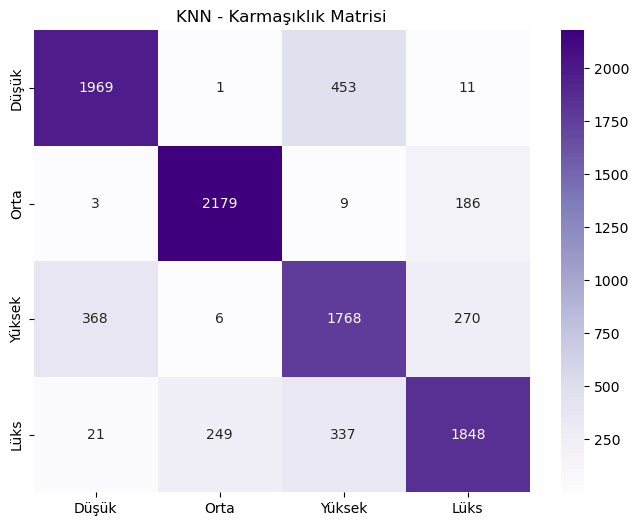

In [27]:
# GÖRSELLEŞTİRMELER 

# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test_cls, y_pred_cls)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Düşük', 'Orta', 'Yüksek', 'Lüks'],
            yticklabels=['Düşük', 'Orta', 'Yüksek', 'Lüks'])
plt.title('KNN - Karmaşıklık Matrisi')
plt.show()

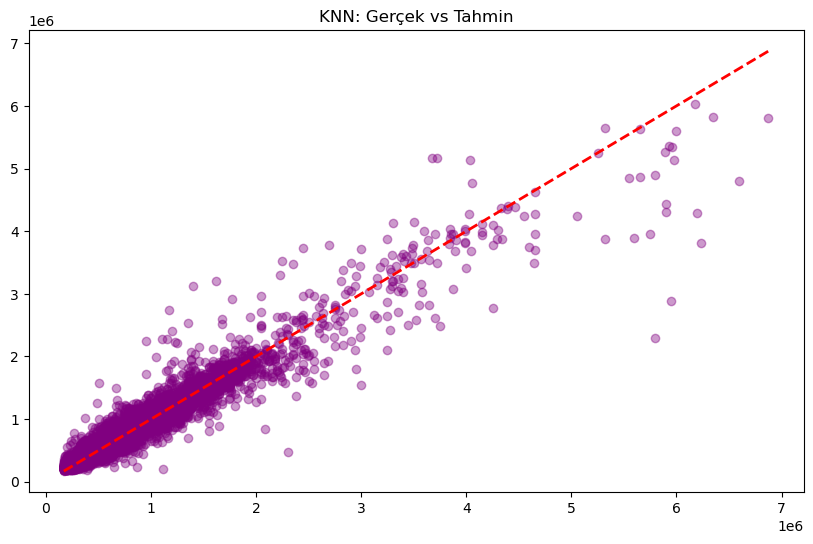

In [28]:
# Gerçek vs Tahmin Grafiği
plt.figure(figsize=(10,6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4, color='purple')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('KNN: Gerçek vs Tahmin')
plt.show()

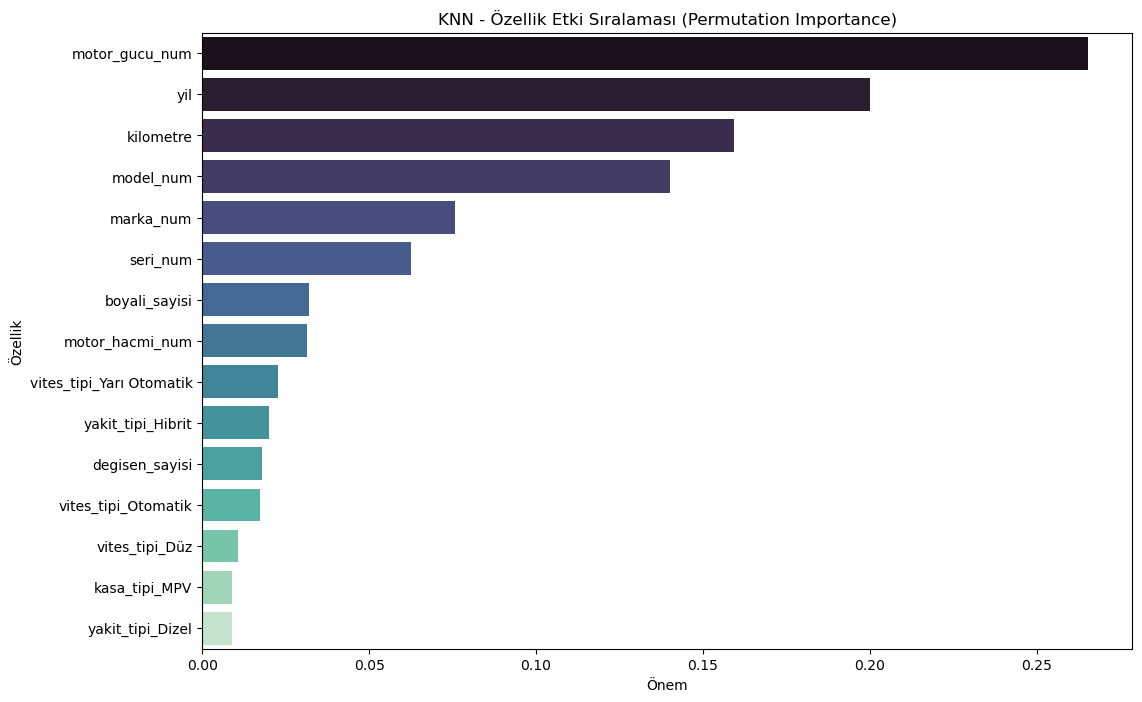

In [31]:
# ÖZELLİK ÖNEM SIRALAMASI (Permutation Importance)
result = permutation_importance(knn_reg, X_test, y_test_reg, n_repeats=10, random_state=42, n_jobs=-1)
knn_importance = pd.DataFrame({'Özellik': X.columns, 'Önem': result.importances_mean}).sort_values(by='Önem', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x="Önem", y="Özellik", data=knn_importance.head(15), palette="mako", hue="Özellik", legend=False)
plt.title('KNN - Özellik Etki Sıralaması (Permutation Importance)')
plt.show()

In [32]:
# MODEL PAKETLEME VE KAYIT 
model_paketi = {
    'regresyon_modeli': knn_reg,
    'siniflandirma_modeli': knn_cls,
    'scaler': scaler,
    'egitim_sutunlari': X.columns.tolist(),
    'alt_limit': alt_limit,
    'ust_limit': ust_limit
}
joblib.dump(model_paketi, "knn.joblib")
print("✅ KNN Modeli ve Scaler başarıyla kaydedildi.")

✅ KNN Modeli ve Scaler başarıyla kaydedildi.


In [35]:
# --- 9. ÖRNEK UYGULAMA ---
def arac_fiyat_tahmin_knn(paketi, yeni_veri):
    m = paketi['regresyon_modeli']
    s = paketi['scaler']
    cols = paketi['egitim_sutunlari']
    
    df = pd.DataFrame([yeni_veri])
    for c in cols:
        if c not in df.columns:
            df[c] = 0
    df = df[cols]
    
    # KNN için veri MUTLAKA ölçeklenmelidir
    df_scaled = s.transform(df)
    return m.predict(df_scaled)[0]

yeni_arac = {
    "yil": 2021,
    "kilometre": 63000,
    "degisen_sayisi": 0,
    "boyali_sayisi": 0,
    "motor_hacmi_num": 1490,
    "motor_gucu_num": 125,
    "marka_num": 50,      # Toyota ID
    "seri_num": 144,      # Corolla ID
    "model_num": 940,     # 1.5 Dream ID
    "vites_tipi_Düz": 0,
    "vites_tipi_Otomatik": 1,
    "vites_tipi_Yarı Otomatik": 0,
    "yakit_tipi_Benzin": 1,
    "yakit_tipi_Dizel": 0,
    "yakit_tipi_Elektrik": 0,
    "yakit_tipi_Hibrit": 0,
    "yakit_tipi_LPG & Benzin": 0,
    "kasa_tipi_Cabrio": 0,
    "kasa_tipi_Coupe": 0,
    "kasa_tipi_Hatchback/3": 0,
    "kasa_tipi_Hatchback/5": 0,
    "kasa_tipi_MPV": 0,
    "kasa_tipi_Pick-up": 0,
    "kasa_tipi_Roadster": 0,
    "kasa_tipi_SUV": 0,
    "kasa_tipi_Sedan": 1,
    "kasa_tipi_Station wagon": 0
}

tahmin_fiyat = arac_fiyat_tahmin_knn(model_paketi, yeni_arac)
print(f"\nGirilen Aracın Tahmini Fiyatı (KNN): {tahmin_fiyat:,.0f} TL")


Girilen Aracın Tahmini Fiyatı (KNN): 1,430,000 TL


C:\Users\omer\anaconda3\envs\usedcar\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
